# Regular Scenario – Fingerprint Method 2

**Scene:** Plaza Mayor, Madrid – a symmetric open square with 4 transmitters at the corners (z=20m).

**Method 2:** Fingerprint based on **5 features per TX**: channel gain, mean delay, RMS delay spread, strongest path delay, and strongest path gain. Position estimation uses kNN with z-score normalized Euclidean distance.

In this LOS-dominated scenario, delay features are expected to add little information beyond channel gain.

## 1. Environment Setup
Install required dependencies.

In [1]:
# Celda 1: Instalar dependencias
!apt-get update
!apt-get install -y llvm
!pip install sionna-rt

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2750 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7221 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.6 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [86.4 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4357 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/univ

In [2]:
!pip uninstall sionna-rt -y
!pip install --upgrade pip

!pip install sionna-rt
!pip install scikit-learn


Found existing installation: sionna-rt 2.0.1
Uninstalling sionna-rt-2.0.1:
  Successfully uninstalled sionna-rt-2.0.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.7 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2
  Using cached sionna_rt-2.0.1-py3-none-any.whl.metadata (4.8 kB)
Using cached sionna_rt-2.0.1-py3-none-any.whl (8.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 23.4 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


## 2. Library Imports
Import Sionna RT, NumPy, Matplotlib, and other required modules.

In [3]:
# después de reiniciar
import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, KFold



no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# (Aquí puedes continuar con el resto de tu código)
print("¡Sionna RT importado con éxito!")

¡Sionna RT importado con éxito!


## 3. Antenna Configuration
Define transmitter (TR38.901) and receiver (dipole, cross-polarized) antenna arrays.

In [4]:
# Configure antenna array for all transmitters
tx_array_config  = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",  
                             polarization="V")
# Configure antenna array for all receivers
rx_array_config = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",  
                             polarization="cross") 


## 4. Path Solver Configuration
Set ray tracing parameters. The `max_depth` parameter is changed manually between executions to evaluate different NLOS conditions.

In [141]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
solver_params = dict(
                 max_depth=6, #max numero de rebotes permitidos
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

## 5. Load 3D Scene
Import the Mitsuba/Sionna scene file.

In [142]:
scene= load_scene("PlazaMayor2/PlazaMayor2.xml", merge_shapes=True) # Merge shapes to speed-up computations

## 6. Transmitter Placement
Place transmitters at fixed positions in the regular (Plaza Mayor) scenario.

In [143]:
scene.tx_array = tx_array_config
scene.rx_array = rx_array_config


np.random.seed(42) 

tx = Transmitter(name="tx",
                position=[-18, 27, 20],
                display_radius=2)
tx1 = Transmitter(name="tx1",
                 position=[18, 27, 20],
                 display_radius=2)
tx2 = Transmitter(name="tx2",
                position=[-18, -27, 20],
                display_radius=2)
tx3 = Transmitter(name="tx3",
                 position=[18, -27, 20],
                 display_radius=2)

# [18, -37, 26]


scene.add(tx)
scene.add(tx1)
scene.add(tx2)
scene.add(tx3)


### RECEPTORES TRAINING GRID SEARCH

## 7. Training Grid (Reference Receivers)
Create a uniform grid of receivers spaced 3m apart for the fingerprint database.

In [144]:
import numpy as np
import mitsuba as mi
from sionna.rt import Receiver
np.random.seed(42) 
# =======================================
# Rejilla 3D con SOLO 2 niveles en Z
# =======================================
def crear_rejilla_2_niveles_z(
    escena,
    x_lim,
    y_lim,
    z_levels,
    paso_xy,
    nombre_base="rx"
):
    # Coordenadas X, Y uniformes
    x_coords = np.arange(x_lim[0], x_lim[1] + paso_xy, paso_xy)
    y_coords = np.arange(y_lim[0], y_lim[1] + paso_xy, paso_xy)

    receptores = []
    idx = 0

    for z in z_levels:
        for x in x_coords:
            for y in y_coords:
                pos = mi.Point3f(float(x), float(y), float(z))
                rx = Receiver(
                    name=f"{nombre_base}_{idx}",
                    position=pos,
                    display_radius=0.5
                )
                escena.add(rx)
                receptores.append(rx)
                idx += 1

    return receptores

# =======================================
# Definición del espacio
# =======================================
x_lim = [-25, 25]
y_lim = [-17, 17]

# SOLO DOS NIVELES EN Z
z_levels = [1.5]

paso_xy = 3.0  # separación en X e Y (metros)

# Crear receptores
receptores_grid = crear_rejilla_2_niveles_z(
    scene,
    x_lim,
    y_lim,
    z_levels,
    paso_xy,
    nombre_base="rx_grid"
)

print(f"\n✔ Receptores creados: {len(receptores_grid)}")

print("\nEjemplo de receptores:") 
for i, rx in enumerate(receptores_grid[:]):
    x, y, z = [rx.position[j].numpy().item() for j in range(3)] 
    print(f"R{i:03d}: ({x:.1f}, {y:.1f}, {z:.1f})")



✔ Receptores creados: 234

Ejemplo de receptores:
R000: (-25.0, -17.0, 1.5)
R001: (-25.0, -14.0, 1.5)
R002: (-25.0, -11.0, 1.5)
R003: (-25.0, -8.0, 1.5)
R004: (-25.0, -5.0, 1.5)
R005: (-25.0, -2.0, 1.5)
R006: (-25.0, 1.0, 1.5)
R007: (-25.0, 4.0, 1.5)
R008: (-25.0, 7.0, 1.5)
R009: (-25.0, 10.0, 1.5)
R010: (-25.0, 13.0, 1.5)
R011: (-25.0, 16.0, 1.5)
R012: (-25.0, 19.0, 1.5)
R013: (-22.0, -17.0, 1.5)
R014: (-22.0, -14.0, 1.5)
R015: (-22.0, -11.0, 1.5)
R016: (-22.0, -8.0, 1.5)
R017: (-22.0, -5.0, 1.5)
R018: (-22.0, -2.0, 1.5)
R019: (-22.0, 1.0, 1.5)
R020: (-22.0, 4.0, 1.5)
R021: (-22.0, 7.0, 1.5)
R022: (-22.0, 10.0, 1.5)
R023: (-22.0, 13.0, 1.5)
R024: (-22.0, 16.0, 1.5)
R025: (-22.0, 19.0, 1.5)
R026: (-19.0, -17.0, 1.5)
R027: (-19.0, -14.0, 1.5)
R028: (-19.0, -11.0, 1.5)
R029: (-19.0, -8.0, 1.5)
R030: (-19.0, -5.0, 1.5)
R031: (-19.0, -2.0, 1.5)
R032: (-19.0, 1.0, 1.5)
R033: (-19.0, 4.0, 1.5)
R034: (-19.0, 7.0, 1.5)
R035: (-19.0, 10.0, 1.5)
R036: (-19.0, 13.0, 1.5)
R037: (-19.0, 16.0, 1.5)

### RECEPTORES TESTING

## 8. Test Receivers (Unknown Positions)
100 receivers at random positions. Their locations will be estimated.

In [145]:
import numpy as np
import mitsuba as mi
from sionna.rt import Receiver

np.random.seed(123)

num_test_rx = 100
receptores_test = []

for i in range(num_test_rx):
    x = np.random.uniform(x_lim[0], x_lim[1])
    y = np.random.uniform(y_lim[0], y_lim[1])
    z = 1.5

    rx = Receiver(
        name=f"rx_test_{i}",
        position=mi.Point3f(float(x), float(y), float(z)),
        display_radius=0.5
    )
    scene.add(rx)
    receptores_test.append(rx)

print(f"\n✔ Receptores a estimar test creados: {len(receptores_test)}")

print("\nEjemplo de receptores:") 
for i, rx in enumerate(receptores_test[:]):
    x, y, z = [rx.position[j].numpy().item() for j in range(3)] 
    print(f"R{i:03d}: ({x:.1f}, {y:.1f}, {z:.1f})")


✔ Receptores a estimar test creados: 100

Ejemplo de receptores:
R000: (9.8, -7.3, 1.5)
R001: (-13.7, 1.7, 1.5)
R002: (11.0, -2.6, 1.5)
R003: (24.0, 6.3, 1.5)
R004: (-1.0, -3.7, 1.5)
R005: (-7.8, 7.8, 1.5)
R006: (-3.1, -15.0, 1.5)
R007: (-5.1, 8.1, 1.5)
R008: (-15.9, -11.0, 1.5)
R009: (1.6, 1.1, 1.5)
R010: (6.7, 11.9, 1.5)
R011: (11.2, 3.8, 1.5)
R012: (11.1, -6.0, 1.5)
R013: (-6.9, -9.2, 1.5)
R014: (-10.3, 4.5, 1.5)
R015: (-20.4, -2.3, 1.5)
R016: (-3.5, -0.2, 1.5)
R017: (-3.7, -6.4, 1.5)
R018: (-3.7, 13.4, 1.5)
R019: (22.2, 0.1, 1.5)
R020: (6.2, -13.1, 1.5)
R021: (-9.1, -2.9, 1.5)
R022: (18.3, -8.5, 1.5)
R023: (-0.8, 16.5, 1.5)
R024: (1.0, 3.8, 1.5)
R025: (-19.0, 11.1, 1.5)
R026: (5.2, 1.5, 1.5)
R027: (-7.9, -6.7, 1.5)
R028: (-4.1, 6.2, 1.5)
R029: (18.8, 0.4, 1.5)
R030: (8.5, 2.9, 1.5)
R031: (6.2, 5.9, 1.5)
R032: (17.1, -14.2, 1.5)
R033: (13.2, -8.7, 1.5)
R034: (-15.3, 2.5, 1.5)
R035: (-20.2, 13.1, 1.5)
R036: (6.4, 7.6, 1.5)
R037: (-24.2, 3.2, 1.5)
R038: (2.8, -11.6, 1.5)
R039: (-17.3

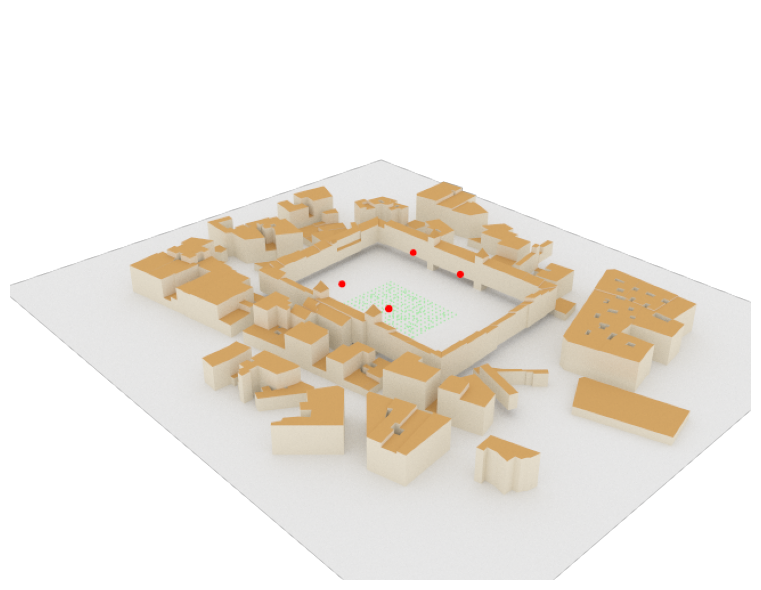

In [28]:
if not no_preview:
    scene.preview();

# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

# Create new camera with different configuration
my_cam = Camera(position=[-300,300,250], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

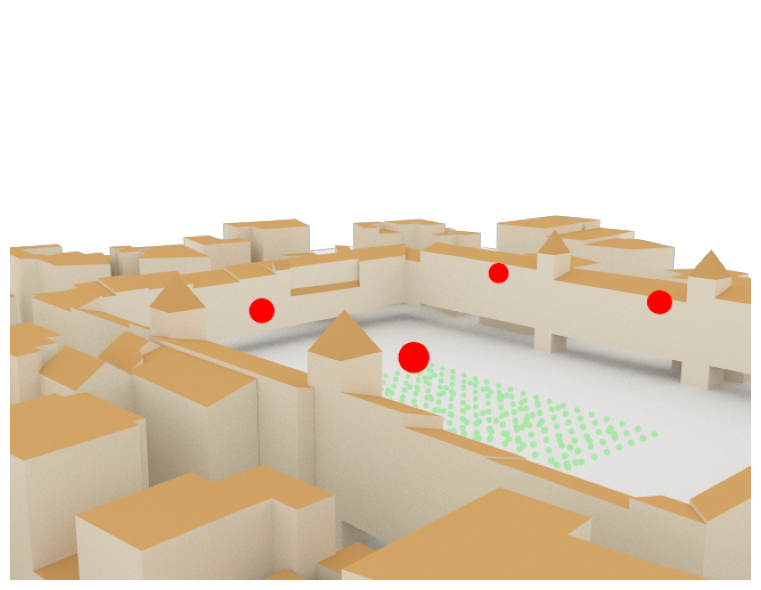

In [17]:
if not no_preview:
    scene.preview();

# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

# Create new camera with different configuration
my_cam = Camera(position=[-100,100,50], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

### FINGERPRINT TRAINING

## 9. Run Ray Tracing
Compute all propagation paths.

In [146]:
paths_scene_caso1 = p_solver(scene=scene, **solver_params)

## 10. Extract Channel Impulse Response (CIR)
Obtain channel coefficients and path delays.

In [147]:
#CIR 
#CASO 1
a_c1, tau_c1 = paths_scene_caso1.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a_c1.shape)
num_paths_c1 = a_c1.shape[4]
print("Num of possible paths from tx to rx: ", num_paths_c1)
# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau_c1.shape)



Shape of a:  (334, 2, 4, 1, 52, 1)
Num of possible paths from tx to rx:  52
Shape of tau:  (334, 2, 4, 1, 52)


## 11. Generate Training Fingerprints (Method 2)
For each grid receiver and each TX, extract 5 features:
- Channel gain (dB)
- Mean delay
- RMS delay spread
- Strongest path delay
- Strongest path gain

In [148]:
fingerprints_grid = []
positions_grid = []

for rx_index, rx in enumerate(receptores_grid):
  fp_rx = []

  for tx_index in range(a_c1.shape[2]):
      a_rt = a_c1[rx_index, 0, tx_index, 0, :, 0]
      tau_rt = tau_c1[rx_index, 0, tx_index, 0, :]

      power = np.abs(a_rt)**2
      total_power = np.sum(power) + 1e-12

      channel_gain = 10 * np.log10(total_power)
      mean_delay = np.sum(power * tau_rt) / total_power
      rms_delay = np.sqrt(np.sum(power * (tau_rt - mean_delay)**2) / total_power)
      strongest_idx = np.argmax(power)
      tau_max = tau_rt[strongest_idx]
      g_max = 10 * np.log10(power[strongest_idx] + 1e-12)

      fp_rx.extend([channel_gain, mean_delay, rms_delay, tau_max, g_max])

  fingerprints_grid.append(fp_rx)
  positions_grid.append(np.array(rx.position))

fingerprints_grid = np.array(fingerprints_grid)
positions_grid = np.array(positions_grid)

print(f"Fingerprint shape: {fingerprints_grid.shape}")
print(f"Features per TX: [G_channel, tau_mean, tau_RMS, tau_max, G_max]")
print(f"Num TX: {a_c1.shape[2]}, Total features: {a_c1.shape[2] * 5}\n")

for i in range(5):
  print(f"Rx{i}: {fingerprints_grid[i]}")

Fingerprint shape: (234, 20)
Features per TX: [G_channel, tau_mean, tau_RMS, tau_max, G_max]
Num TX: 4, Total features: 20

Rx0: [-8.4830994e+01  4.2872387e-07  1.0310385e-07  4.1584397e-07
 -8.8515900e+01 -9.2879135e+01  3.9737390e-07  1.4426053e-07
  4.5474610e-07 -9.5130424e+01 -8.5742645e+01  4.9333744e-07
  1.2750574e-07  5.2555157e-07 -9.0733330e+01 -8.2476845e+01
  3.0988494e-07  4.7353208e-08  3.0050396e-07 -8.5870575e+01]
Rx1: [-8.63449097e+01  4.33885987e-07  1.23665600e-07  4.21851155e-07
 -8.83258743e+01 -8.60257034e+01  2.86065813e-07  1.01904675e-07
  2.49104801e-07 -8.70182495e+01 -8.68528900e+01  4.63159694e-07
  1.47631397e-07  5.22992480e-07 -9.10950851e+01 -8.34958496e+01
  3.16994004e-07  7.19128082e-08  2.98504318e-07 -8.59651184e+01]
Rx2: [-8.8865013e+01  4.8055875e-07  1.8943682e-07  4.6863735e-07
 -9.3857262e+01 -9.3611565e+01  3.9367953e-07  1.6241445e-07
  4.6544122e-07 -9.4868256e+01 -8.5830193e+01  4.8526914e-07
  1.4761167e-07  5.1970153e-07 -9.1480621e+01 

### FINGERPRINT TESTING

## 12. Generate Test Fingerprints (Method 2)
Same 5-feature extraction for test receivers. Uses `offset` for correct array indexing.

In [149]:
fingerprints_test = []
positions_test = []

offset = len(receptores_grid)

for i, rx in enumerate(receptores_test):
  rx_index = offset + i
  fp_rx = []
  for tx_index in range(a_c1.shape[2]):
      a_rt = a_c1[rx_index, 0, tx_index, 0, :, 0]
      tau_rt = tau_c1[rx_index, 0, tx_index, 0, :]
      power = np.abs(a_rt)**2
      total_power = np.sum(power) + 1e-12
      channel_gain = 10 * np.log10(total_power)
      mean_delay = np.sum(power * tau_rt) / total_power
      rms_delay = np.sqrt(np.sum(power * (tau_rt - mean_delay)**2) / total_power)
      strongest_idx = np.argmax(power)
      tau_max = tau_rt[strongest_idx]
      g_max = 10 * np.log10(power[strongest_idx] + 1e-12)
      fp_rx.extend([channel_gain, mean_delay, rms_delay, tau_max, g_max])
  fingerprints_test.append(fp_rx)
  positions_test.append(np.array(rx.position))

fingerprints_test = np.array(fingerprints_test)
positions_test = np.array(positions_test)
print(f"Fingerprint test shape: {fingerprints_test.shape}")

Fingerprint test shape: (100, 20)


### TESTING MAXDEPTH 0 NO VALE PORQUE NO HAY RETARDO

### MAXDEPTH 0

OPCION 0. COMPARAR CON DISTANCIA EUCLIDEA

## 13. Position Estimation (Normalized kNN) & Results
Normalize features using z-score (filtering zero-variance features). Then apply kNN with Euclidean distance on the normalized space. Results shown as CDF and Mean/Median plots.

Features válidas: 8 de 20


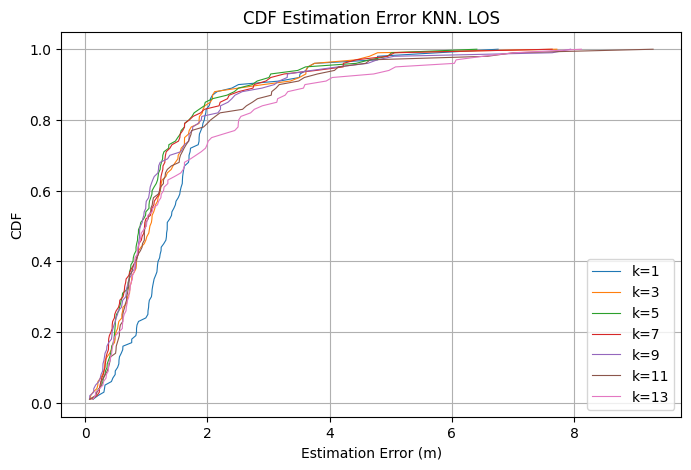

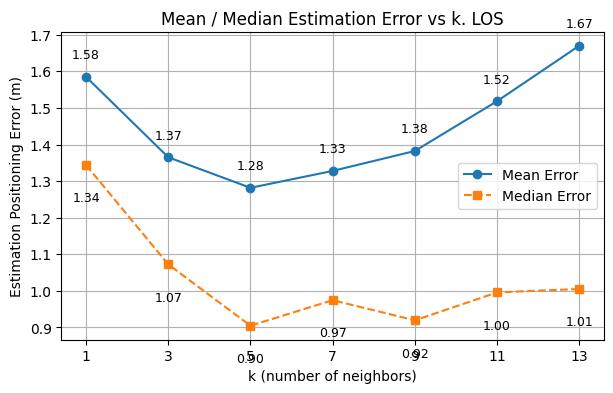

k=1: mean=1.58 m
k=3: mean=1.37 m
k=5: mean=1.28 m
k=7: mean=1.33 m
k=9: mean=1.38 m
k=11: mean=1.52 m
k=13: mean=1.67 m


In [120]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)

ks = [1, 3, 5, 7, 9, 11, 13]

# Normalización z-score filtrando features sin varianza
mu = np.mean(fingerprints_grid, axis=0)
sigma = np.std(fingerprints_grid, axis=0)
valid = sigma > 1e-10
print(f"Features válidas: {np.sum(valid)} de {len(sigma)}")

train_norm = (fingerprints_grid[:, valid] - mu[valid]) / sigma[valid]
test_norm = (fingerprints_test[:, valid] - mu[valid]) / sigma[valid]

# kNN
errores_por_k = {k: [] for k in ks}
for i in range(len(test_norm)):
  distancias = np.linalg.norm(train_norm - test_norm[i], axis=1)
  for k in ks:
      idx = np.argsort(distancias)[:k]
      pos_est = np.mean(positions_grid[idx], axis=0)
      error = np.linalg.norm(pos_est - positions_test[i])
      errores_por_k[k].append(error)

# Resultados
mean_errors = []
median_errors = []
for k in ks:
  errores = np.array(errores_por_k[k])
  mean_errors.append(np.mean(errores))
  median_errors.append(np.median(errores))

# CDF
plt.figure(figsize=(8,5))
for k in ks:
  errores = np.sort(errores_por_k[k])
  cdf = np.arange(1, len(errores)+1) / len(errores)
  plt.plot(errores, cdf, label=f'k={k}', linewidth=0.8)
plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. LOS")
plt.grid(True)
plt.legend()
plt.show()

# Mean/Median vs k
plt.figure(figsize=(7,4))
plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")
for k, err in zip(ks, mean_errors):
  plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)
for k, err in zip(ks, median_errors):
  plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)
plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. LOS")
plt.grid(True)
plt.legend()
plt.xticks(range(1, 14, 2))
plt.show()

for k, m in zip(ks, mean_errors):
  print(f"k={k}: mean={m:.2f} m")


### MAXDEPTH 1

Features válidas: 20 de 20


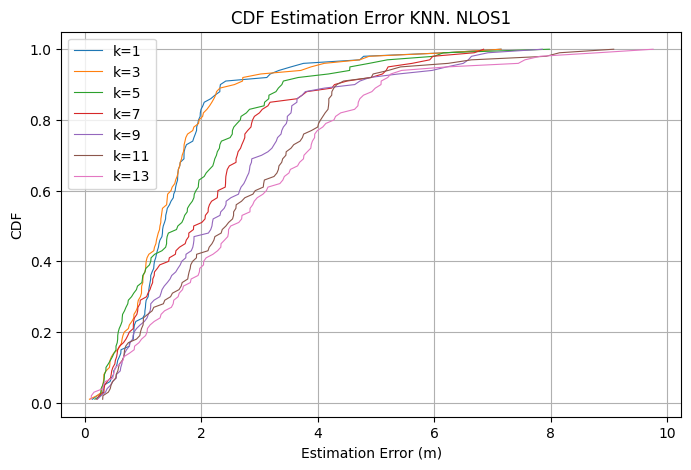

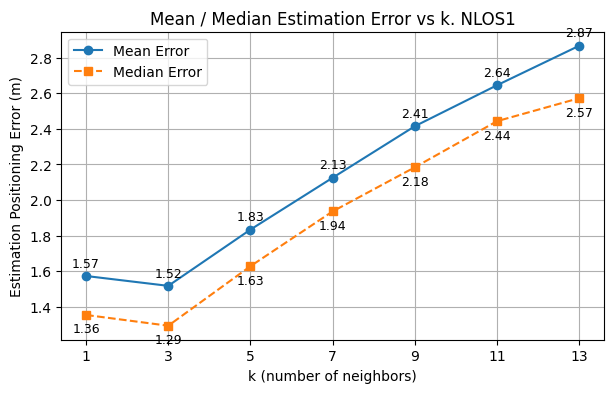

k=1: mean=1.57 m
k=3: mean=1.52 m
k=5: mean=1.83 m
k=7: mean=2.13 m
k=9: mean=2.41 m
k=11: mean=2.64 m
k=13: mean=2.87 m


In [130]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)

ks = [1, 3, 5, 7, 9, 11, 13]

# Normalización z-score filtrando features sin varianza
mu = np.mean(fingerprints_grid, axis=0)
sigma = np.std(fingerprints_grid, axis=0)
valid = sigma > 1e-10
print(f"Features válidas: {np.sum(valid)} de {len(sigma)}")

train_norm = (fingerprints_grid[:, valid] - mu[valid]) / sigma[valid]
test_norm = (fingerprints_test[:, valid] - mu[valid]) / sigma[valid]

# kNN
errores_por_k = {k: [] for k in ks}
for i in range(len(test_norm)):
  distancias = np.linalg.norm(train_norm - test_norm[i], axis=1)
  for k in ks:
      idx = np.argsort(distancias)[:k]
      pos_est = np.mean(positions_grid[idx], axis=0)
      error = np.linalg.norm(pos_est - positions_test[i])
      errores_por_k[k].append(error)

# Resultados
mean_errors = []
median_errors = []
for k in ks:
  errores = np.array(errores_por_k[k])
  mean_errors.append(np.mean(errores))
  median_errors.append(np.median(errores))

# CDF
plt.figure(figsize=(8,5))
for k in ks:
  errores = np.sort(errores_por_k[k])
  cdf = np.arange(1, len(errores)+1) / len(errores)
  plt.plot(errores, cdf, label=f'k={k}', linewidth=0.8)
plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS1")
plt.grid(True)
plt.legend()
plt.show()

# Mean/Median vs k
plt.figure(figsize=(7,4))
plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")
for k, err in zip(ks, mean_errors):
  plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)
for k, err in zip(ks, median_errors):
  plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)
plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS1")
plt.grid(True)
plt.legend()
plt.xticks(range(1, 14, 2))
plt.show()

for k, m in zip(ks, mean_errors):
  print(f"k={k}: mean={m:.2f} m")


### MAXDEPTH 2

## 13. Position Estimation (Normalized kNN) & Results
Normalize features using z-score (filtering zero-variance features). Then apply kNN with Euclidean distance on the normalized space. Results shown as CDF and Mean/Median plots.

Features válidas: 20 de 20


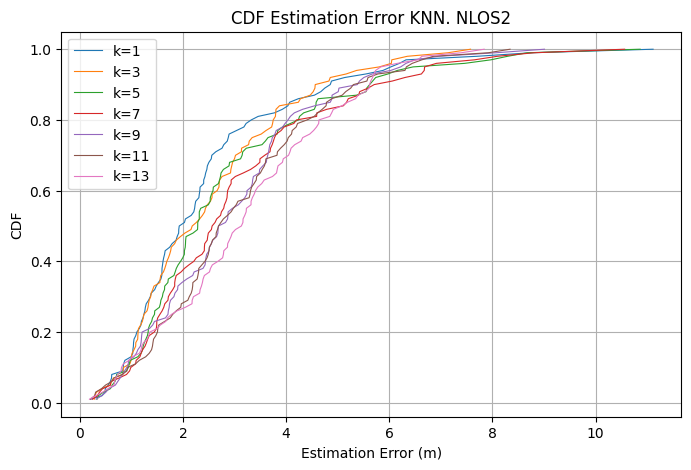

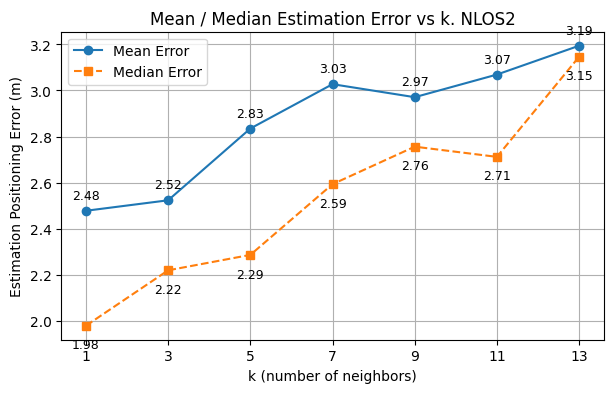

k=1: mean=2.48 m
k=3: mean=2.52 m
k=5: mean=2.83 m
k=7: mean=3.03 m
k=9: mean=2.97 m
k=11: mean=3.07 m
k=13: mean=3.19 m


In [140]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)

ks = [1, 3, 5, 7, 9, 11, 13]

# Normalización z-score filtrando features sin varianza
mu = np.mean(fingerprints_grid, axis=0)
sigma = np.std(fingerprints_grid, axis=0)
valid = sigma > 1e-10
print(f"Features válidas: {np.sum(valid)} de {len(sigma)}")

train_norm = (fingerprints_grid[:, valid] - mu[valid]) / sigma[valid]
test_norm = (fingerprints_test[:, valid] - mu[valid]) / sigma[valid]

# kNN
errores_por_k = {k: [] for k in ks}
for i in range(len(test_norm)):
  distancias = np.linalg.norm(train_norm - test_norm[i], axis=1)
  for k in ks:
      idx = np.argsort(distancias)[:k]
      pos_est = np.mean(positions_grid[idx], axis=0)
      error = np.linalg.norm(pos_est - positions_test[i])
      errores_por_k[k].append(error)

# Resultados
mean_errors = []
median_errors = []
for k in ks:
  errores = np.array(errores_por_k[k])
  mean_errors.append(np.mean(errores))
  median_errors.append(np.median(errores))

# CDF
plt.figure(figsize=(8,5))
for k in ks:
  errores = np.sort(errores_por_k[k])
  cdf = np.arange(1, len(errores)+1) / len(errores)
  plt.plot(errores, cdf, label=f'k={k}', linewidth=0.8)
plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS2")
plt.grid(True)
plt.legend()
plt.show()

# Mean/Median vs k
plt.figure(figsize=(7,4))
plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")
for k, err in zip(ks, mean_errors):
  plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)
for k, err in zip(ks, median_errors):
  plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)
plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS2")
plt.grid(True)
plt.legend()
plt.xticks(range(1, 14, 2))
plt.show()

for k, m in zip(ks, mean_errors):
  print(f"k={k}: mean={m:.2f} m")


### MAXDEPTH 6

Features válidas: 20 de 20


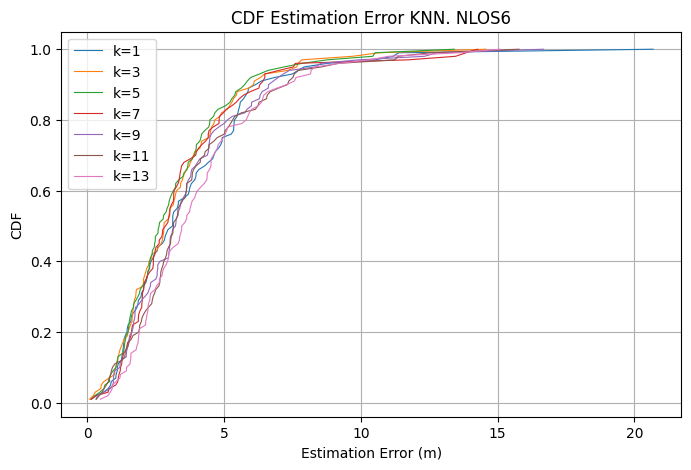

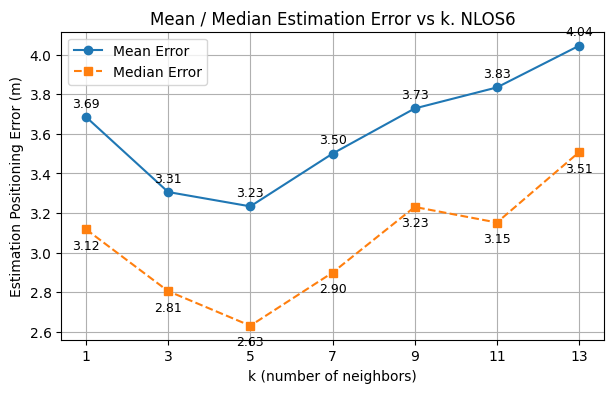

k=1: mean=3.69 m
k=3: mean=3.31 m
k=5: mean=3.23 m
k=7: mean=3.50 m
k=9: mean=3.73 m
k=11: mean=3.83 m
k=13: mean=4.04 m


In [150]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)

ks = [1, 3, 5, 7, 9, 11, 13]

# Normalización z-score filtrando features sin varianza
mu = np.mean(fingerprints_grid, axis=0)
sigma = np.std(fingerprints_grid, axis=0)
valid = sigma > 1e-10
print(f"Features válidas: {np.sum(valid)} de {len(sigma)}")

train_norm = (fingerprints_grid[:, valid] - mu[valid]) / sigma[valid]
test_norm = (fingerprints_test[:, valid] - mu[valid]) / sigma[valid]

# kNN
errores_por_k = {k: [] for k in ks}
for i in range(len(test_norm)):
  distancias = np.linalg.norm(train_norm - test_norm[i], axis=1)
  for k in ks:
      idx = np.argsort(distancias)[:k]
      pos_est = np.mean(positions_grid[idx], axis=0)
      error = np.linalg.norm(pos_est - positions_test[i])
      errores_por_k[k].append(error)

# Resultados
mean_errors = []
median_errors = []
for k in ks:
  errores = np.array(errores_por_k[k])
  mean_errors.append(np.mean(errores))
  median_errors.append(np.median(errores))

# CDF
plt.figure(figsize=(8,5))
for k in ks:
  errores = np.sort(errores_por_k[k])
  cdf = np.arange(1, len(errores)+1) / len(errores)
  plt.plot(errores, cdf, label=f'k={k}', linewidth=0.8)
plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS6")
plt.grid(True)
plt.legend()
plt.show()

# Mean/Median vs k
plt.figure(figsize=(7,4))
plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")
for k, err in zip(ks, mean_errors):
  plt.text(k, err + 0.05, f"{err:.2f}", ha='center', fontsize=9)
for k, err in zip(ks, median_errors):
  plt.text(k, err - 0.1, f"{err:.2f}", ha='center', fontsize=9)
plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS6")
plt.grid(True)
plt.legend()
plt.xticks(range(1, 14, 2))
plt.show()

for k, m in zip(ks, mean_errors):
  print(f"k={k}: mean={m:.2f} m")
